In [64]:
# Import Libraries
import matplotlib.pyplot as plt
import pandas as pd

In [65]:
# Import datasets
drupal = pd.read_csv('/lakehouse/default/Files/nccpss_data.csv')
registry = pd.read_excel('/lakehouse/default/Files/PSS REGISTRY.xlsx')

In [66]:
# View column names
print("Drupal Columns: ", drupal.columns)
print("Registry Columns: ", registry.columns)

Drupal Columns:  Index(['DUID', 'Application', 'First', 'Last', 'Email', 'ModState', 'DOB',
       'Track', 'Employed as a CPSS', 'County Residence', 'County Employment',
       'Employment status', 'Employer', 'Hourly', 'Hours per week',
       'Years Employed', 'Months Employed', 'field_app_other_race', 'Gender',
       'Education level', 'Race/Ethnicity', 'Address1', 'Address2', 'City',
       'Zip Code', 'State'],
      dtype='object')
Registry Columns:  Index(['ID', 'Last Name', 'First Name', 'Address', 'City', 'County', 'State',
       'Zip Code', 'Date of Birth', 'Phone Number', 'Email address', 'Veteran',
       'Certification Status', 'Checklist', 'Completed application',
       'Demonstrated 1 year recovery', 'NC certified training',
       '20 hr training', 'Reference form 1', 'Reference form 2',
       'Application fee', 'Certificate Number', 'Date of Certification',
       'Date of Current Recertification', 'NOTES', 'Time employed as PSS',
       'Employed as PSS?', 'Gende

In [67]:
# Source - registry
# Certification Status
cert_stat = registry['Certification Status'].value_counts()
print(cert_stat)

Certification Status
Lapsed                         7424
Current                        5921
current                         342
In-Training                      40
Pending                          33
Lapsed_x000D_\nLapsed            26
Deceased                          6
lapsed                            4
On Hold                           3
Current_x000D_                    2
Current_x000D_\nLapsed            1
Denied                            1
2023-6136-01_x000D_\nLapsed       1
Lased                             1
Name: count, dtype: int64


In [89]:
# Source - registry
# Clean certificate status values
registry['Certification Status'] = registry['Certification Status'].str.strip().str.lower()

# Recode variations to cleaner labels
registry.loc[registry['Certification Status'].str.contains('current', na=False), 'Certification Status'] = 'current'
registry.loc[registry['Certification Status'].str.contains('lapsed', na=False), 'Certification Status'] = 'lapsed'
registry.loc[registry['Certification Status'].str.contains('lased', na=False), 'Certification Status'] = 'lapsed'

In [68]:
# Source - Drupal
# Gender
gender_count = registry['Gender'].value_counts()
print(gender_count)

Gender
Female           7569
Male             4399
female            693
male              594
not specified     312
Non-Binary         27
Other              18
Non-binary          6
other               2
Mpn-Binary          1
M                   1
White               1
Name: count, dtype: int64


In [84]:
# Source - Drupal
# Clean gender values
drupal["Gender"] = drupal['Gender'].str.strip().str.lower()

# Recode variations to cleaner 
# Relabel any value containing 'female'
drupal.loc[drupal['Gender'].str.contains('femal', na=False), 'Gender'] = 'Female'
drupal.loc[drupal['Gender'].str.contains('woman', na=False), 'Gender'] = 'Female'
drupal.loc[drupal['Gender'].str.contains('women', na=False), 'Gender'] = 'Female'
drupal.loc[drupal['Gender'].str.contains('she', na=False), 'Gender'] = 'Female'
drupal.loc[drupal['Gender'].str.contains('him', na=False), 'Gender'] = 'Male'
drupal.loc[drupal['Gender'].str.contains('make', na=False), 'Gender'] = 'Male'
drupal.loc[drupal['Gender'].str.contains('binary', na=False), 'Gender'] = 'Non-binary'

# 'male' must come AFTER 'female' — use word boundary to avoid partial matches
drupal.loc[
    drupal['Gender'].str.contains(r'\bmale\b', case=False, na=False) &
    ~drupal['Gender'].str.contains('female', case=False, na=False),
    'Gender'
] = 'Male'

# 'male' must come AFTER 'female' — use word boundary to avoid partial matches
drupal.loc[
    drupal['Gender'].str.contains(r'\bman\b', case=False, na=False) &
    ~drupal['Gender'].str.contains('woman', case=False, na=False),
    'Gender'
] = 'Male'

# Drop non-gendered values
drupal = drupal[drupal['Gender'] != 'african american']


In [70]:
%pip install rapidfuzz

Note: you may need to restart the kernel to use updated packages.


In [85]:
# Source - Drupal
# Fix typos in Gender column

# Import fuzz library -- the following code was written with conceptual assisted from Claude
from rapidfuzz import process, fuzz

STANDARD_LABELS = ['Male', 'Female', 'Non-binary', 'Transgender']
FUZZY_THRESHOLD = 80          # 0–100; lower = more aggressive matching
ALREADY_CLEAN = set(STANDARD_LABELS)

def fuzzy_recode(value: str) -> str:
    """Return the closest standard label if confidence >= threshold, else original."""
    if not isinstance(value, str) or value in ALREADY_CLEAN:
        return value
    match, score, _ = process.extractOne(
        value.lower(),
        [lbl.lower() for lbl in STANDARD_LABELS],
        scorer=fuzz.WRatio,
    )
    if score >= FUZZY_THRESHOLD:
        # Return properly-cased standard label
        return STANDARD_LABELS[[lbl.lower() for lbl in STANDARD_LABELS].index(match)]
    return value  # leave unrecognised values untouched

drupal['Gender'] = drupal['Gender'].apply(fuzzy_recode)

# List remaining values
non_standard = drupal.loc[~drupal['Gender'].isin(ALREADY_CLEAN), 'Gender'].value_counts()
if not non_standard.empty:
    print("⚠️  Non-standard Gender values remaining (review manually):")
    print(non_standard.to_string())
else:
    print("✅  All Gender values successfully recoded.")

⚠️  Non-standard Gender values remaining (review manually):
Gender
queer; trans-masc    1
transmasculine       1
genderfluid          1


In [72]:
# drupal.loc[~drupal['Gender'].isin([
#     'Female','Male','Non-binary', 'Transgender'
# ]), 'Gender'] = 'Other'

In [79]:
# Source - Drupal
# Convert Date of Birth column and calculate age for histogram
drupal['DOB'] = pd.to_datetime(drupal['DOB'])
drupal['age'] = (pd.Timestamp.now() - drupal['DOB']).dt.days // 365

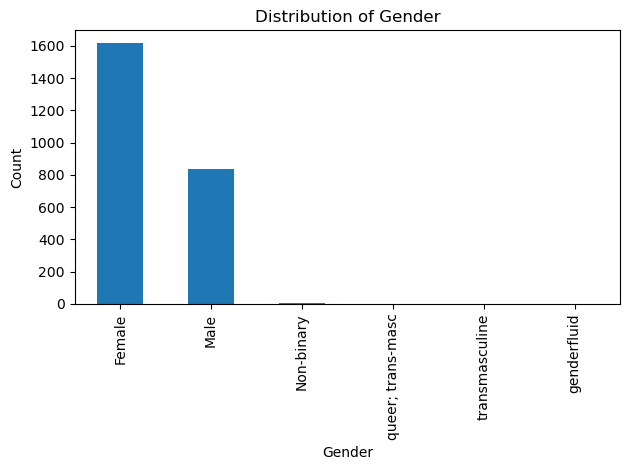

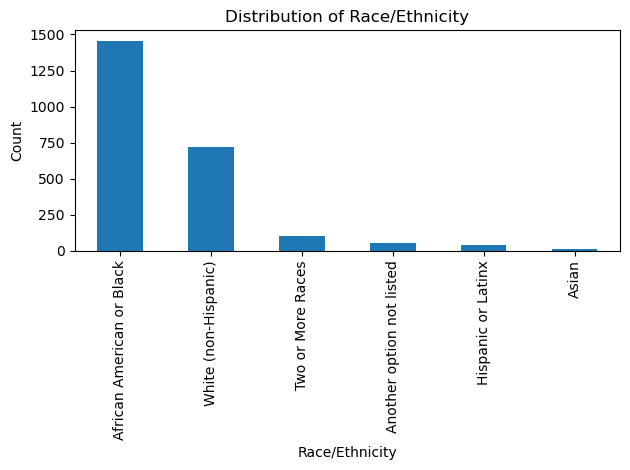

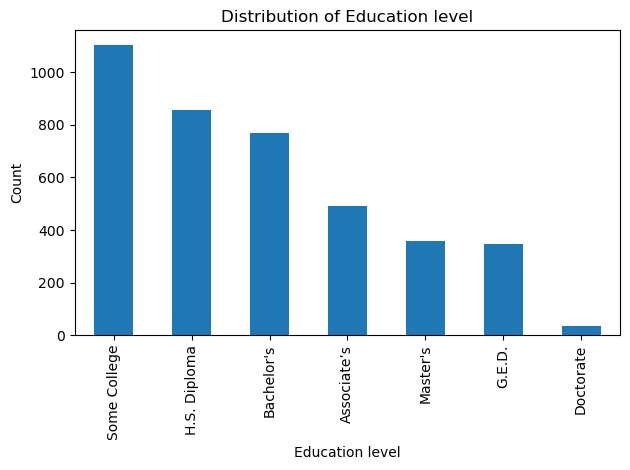

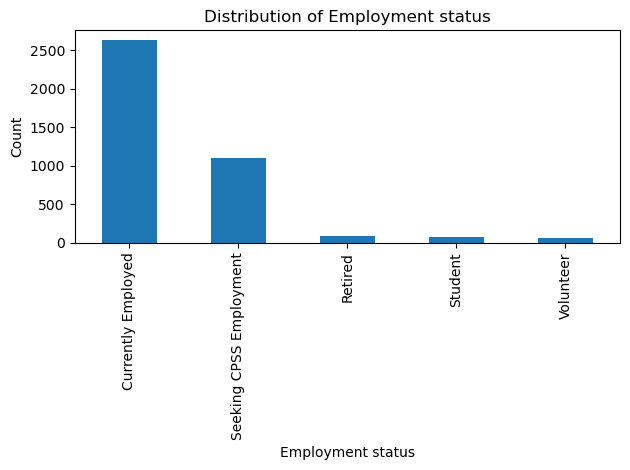

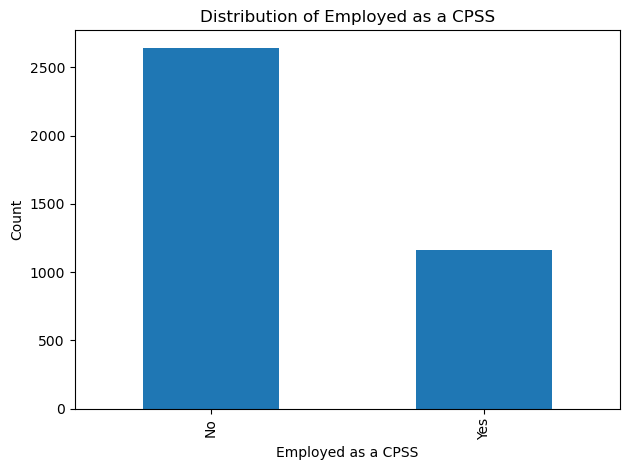

In [86]:
# Source -- Drupal
# Categorical Demographics
categorical_cols = [
    'Gender',
    'Race/Ethnicity',
    'Education level',
    'Employment status',
    'Employed as a CPSS'
]

for c in categorical_cols:
    plt.figure()
    drupal[c].value_counts(dropna = True).plot(kind = 'bar')
    plt.title(f'Distribution of {c}')
    plt.xlabel(c)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

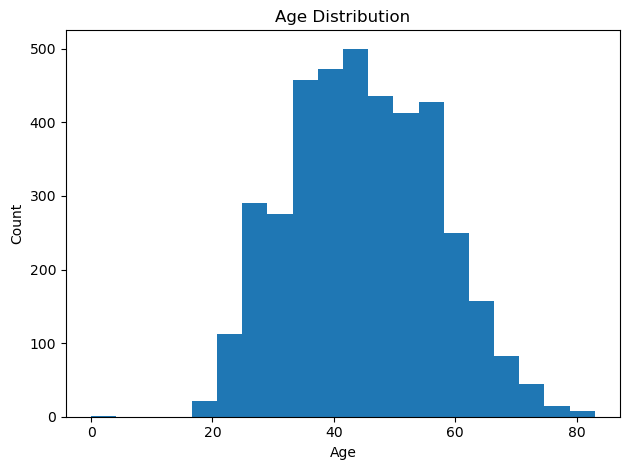

In [75]:
# Source -- Drupal

# Age Distribution

plt.figure()
plt.hist(drupal['age'].dropna(), bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

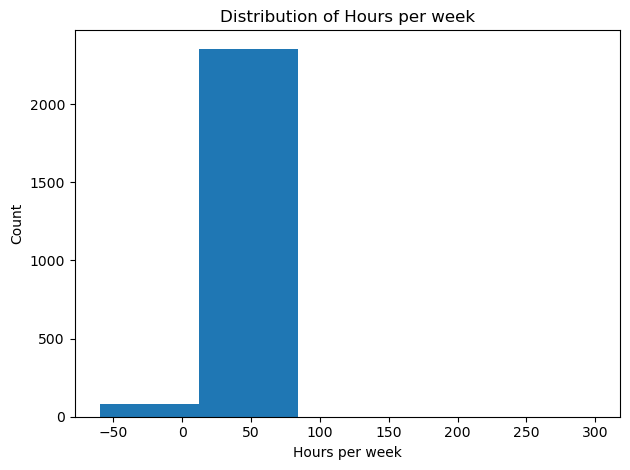

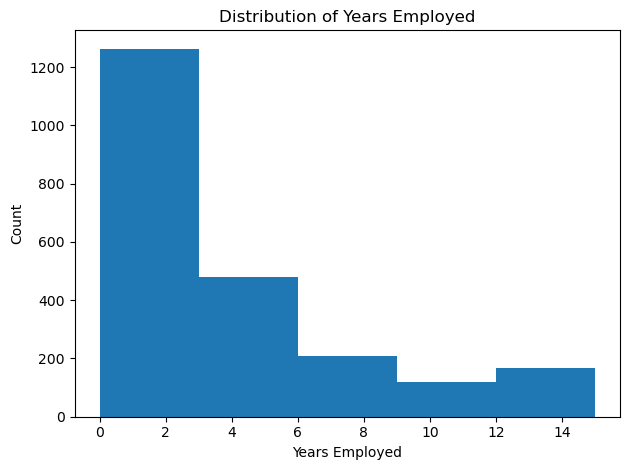

In [83]:
# Source -- Drupal

# Numeric Employment Variables

drupal['Years Employed'] = drupal['Years Employed'].replace('Zero', 0)

numeric_cols = [
    'Hours per week',
    'Years Employed'
]

for c in numeric_cols:
    drupal[c] = pd.to_numeric(drupal[c])
    plt.figure()
    plt.hist(drupal[c].dropna(), bins= 5)
    plt.title(f'Distribution of {c}')
    plt.xlabel(c)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

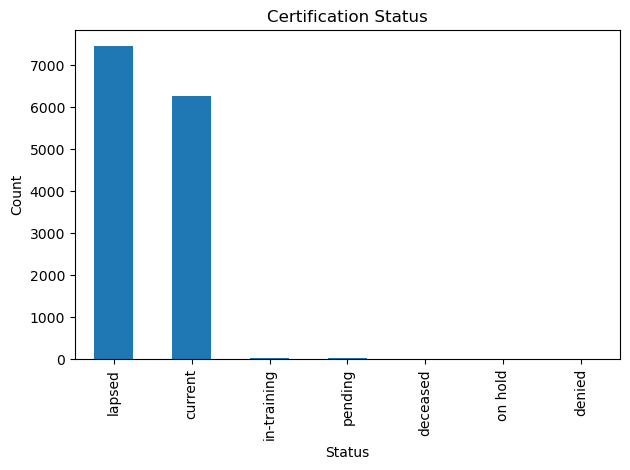

In [95]:
# Visualize Certification status

plt.figure()
registry['Certification Status'].value_counts(dropna = True).plot(kind = 'bar')
plt.title('Certification Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()